## Import libs and create controller

In [2]:
import json

from dotenv import load_dotenv

from src.app.controllers.app_controller import Controller
from src.prompts.system_prompt import system_prompt_gemini_answer_agent, system_prompt_gemini_query_preprocess_agent

In [3]:
load_dotenv()

controller = Controller(
    text_index_path="../data/faiss/corpus_faiss_by_chunks.index",
    text_metadata_path="../data/metadata/corpus_faiss_metadata_chunks.pkl",
    image_index_path="../data/faiss/image.index",
    image_metadata_path="../data/metadata/metadata_image.pkl",
    qa_system_prompt=system_prompt_gemini_answer_agent,
    translator_system_prompt=system_prompt_gemini_query_preprocess_agent
)

## Load Data

In [4]:
def load_json_file(filepath: str):
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)
    
json_results = load_json_file("rag_questions.json")

In [5]:
questions = []
ground_truth = []

for q in json_results:
    questions.append(q['question'])
    ground_truth.append(q['ground_truth'])

## Processing questions by Rag

In [ ]:
results = []

for idx, q in enumerate(questions, 1):
    print(f"Processing Q{idx}: {q}")
    try:
        urls_markdown, images, html_output, content = controller.retrieve(q, html_output_text=False, content=True)
        results.append({
            "question": q,
            "article_urls": urls_markdown,
            "image_urls": images,
            "html_answer": html_output,
            "content": content
        })
    except Exception as e:
        print(f"Error on question {idx}: {e}")
        results.append({
            "question": q,
            "error": str(e)
        })

In [7]:
def get_documents(input):
    contents = []
    for text in input:
        contents.append(text['content'])
    
    return contents

In [8]:
answers = []
documents = []

for answer in results:
    answers.append(answer['html_answer'])
    documents.append(get_documents(answer['content']))

In [ ]:
documents[0]

## Create dataset for ragas evaluate

In [9]:
from datasets import Dataset

def prepare_ragas_dataset(qa, documents, reference_answers, model_answers):
    questions = []
    ground_truths = []
    answers = []
    contexts = []
    
    for entry, doc_list, ref, model_answer in zip(qa, documents, reference_answers, model_answers):
        questions.append(entry)
        ground_truths.append(ref)
        answers.append(model_answer)
    
        retrieved_contexts = [doc for doc in doc_list]
        contexts.append(retrieved_contexts)

    return Dataset.from_dict({
        "question": questions,
        "contexts": contexts,
        "answer": answers,
        "ground_truth": ground_truths
    })

INFO:datasets:PyTorch version 2.3.0 available.


In [10]:
res = prepare_ragas_dataset(qa=questions, documents=documents, reference_answers=ground_truth, model_answers=answers)

In [11]:
res

Dataset({
    features: ['question', 'contexts', 'answer', 'ground_truth'],
    num_rows: 26
})

## Evaluate model with new chunking method for text

In [12]:
from ragas import evaluate
from ragas.metrics import (
    context_precision,
    context_recall,
    answer_relevancy,
    faithfulness
)

In [13]:
results = evaluate(
    res,
    metrics=[
        context_precision,
        context_recall,
        answer_relevancy,
        faithfulness,
    ]
)

print(results)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:

{'context_precision': 0.5105, 'context_recall': 0.7167, 'answer_relevancy': 0.6653, 'faithfulness': 0.9127}


## Evaluate model with reranker

In [13]:
results = evaluate(
    res,
    metrics=[
        context_precision,
        context_recall,
        answer_relevancy,
        faithfulness,
    ]
)

print(results)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:

{'context_precision': 0.6810, 'context_recall': 0.6833, 'answer_relevancy': 0.6578, 'faithfulness': 0.8444}


## Evaluate model with better k for retrival and reranker and better prompt

In [13]:
results = evaluate(
    res,
    metrics=[
        context_precision,
        context_recall,
        answer_relevancy,
        faithfulness,
    ]
)

print(results)

Evaluating:   0%|          | 0/104 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:

{'context_precision': 0.6527, 'context_recall': 0.7300, 'answer_relevancy': 0.8152, 'faithfulness': 0.8567}


## Plot which show difference between models

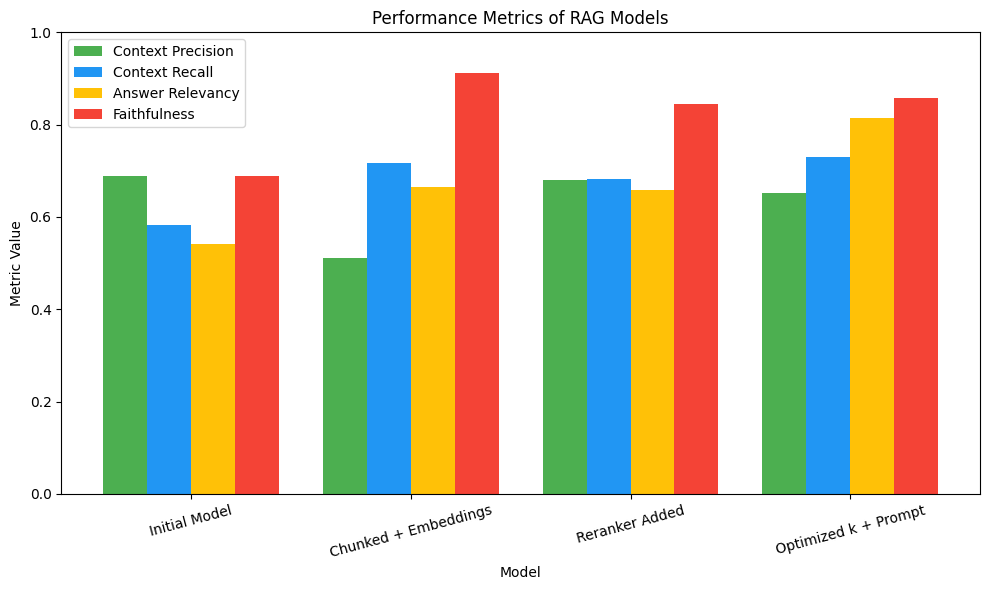

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the four models
models = ["Initial Model", "Chunked + Embeddings", "Reranker Added", "Optimized k + Prompt"]
context_precision = [0.6889, 0.5105, 0.6810, 0.6527]
context_recall = [0.5833, 0.7167, 0.6833, 0.7300]
answer_relevancy = [0.5414, 0.6653, 0.6578, 0.8152]
faithfulness = [0.6889, 0.9127, 0.8444, 0.8567]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = np.arange(len(models))

# Plot bars for each metric
ax.bar(x - bar_width*1.5, context_precision, bar_width, label="Context Precision", color="#4CAF50")
ax.bar(x - bar_width*0.5, context_recall, bar_width, label="Context Recall", color="#2196F3")
ax.bar(x + bar_width*0.5, answer_relevancy, bar_width, label="Answer Relevancy", color="#FFC107")
ax.bar(x + bar_width*1.5, faithfulness, bar_width, label="Faithfulness", color="#F44336")

# Customize the plot
ax.set_xlabel("Model")
ax.set_ylabel("Metric Value")
ax.set_title("Performance Metrics of RAG Models")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0, 1)
ax.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()